In [2]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=9198ba6a3ea2530188aa5695c5ffb0797bb8d727bde6cfa7794ba1caebe7f195
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd
from apyori import apriori
import matplotlib.pyplot as plt

In [5]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Market_Basket_Optimisation.csv', header = None)

In [6]:
dataset

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Exploratory Data Analysis (EDA)

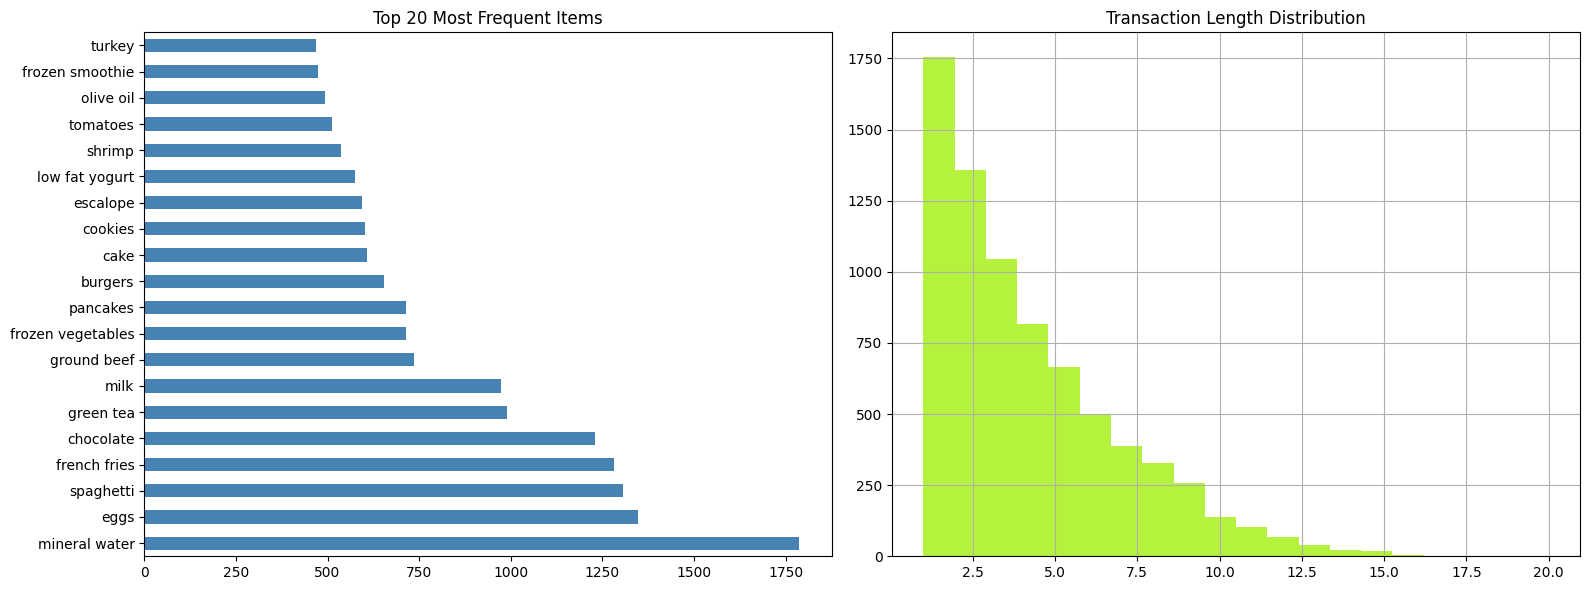

Avg items per transaction: 3.91


In [12]:
all_items = dataset.values.flatten()
item_freq = pd.Series(all_items).dropna()
item_freq = item_freq[item_freq != 'nan'].value_counts().head(20)

tx_lengths = dataset.apply(lambda r: r.notna().sum(), axis=1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

item_freq.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Most Frequent Items')

tx_lengths.hist(bins=20, ax=axes[1], color='#b5f23d')
axes[1].set_title('Transaction Length Distribution')

plt.tight_layout()
plt.show()

print(f"Avg items per transaction: {tx_lengths.mean():.2f}")

Data Preprocessing

In [8]:
transactions = dataset.apply(
    lambda row: [item for item in row if pd.notna(item)],
    axis=1
).tolist()

print(f"Transactions ready: {len(transactions)}")
print(f"Sample: {transactions[0]}")

Transactions ready: 7501
Sample: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']


Apriori Function & Results

In [9]:
def run_apriori(transactions, min_support=0.003, min_confidence=0.2, min_lift=3):
    raw = list(apriori(transactions, min_support=min_support,
                       min_confidence=min_confidence, min_lift=min_lift,
                       min_length=2, max_length=2))

    if not raw:
        print("No rules found.")
        return pd.DataFrame()

    rows = [(tuple(r[2][0][0])[0], tuple(r[2][0][1])[0],
             r[1], r[2][0][2], r[2][0][3]) for r in raw]

    df = pd.DataFrame(rows, columns=['LHS', 'RHS', 'Support', 'Confidence', 'Lift'])
    return df.sort_values('Lift', ascending=False).reset_index(drop=True)

df = run_apriori(transactions)
print(f"Rules found: {len(df)}")
df

Rules found: 9


,LHS,RHS,Support,Confidence,Lift
0,fromage blanc,honey,0.003333,0.245098,5.164271
1,light cream,chicken,0.004533,0.290598,4.843951
2,pasta,escalope,0.005866,0.372881,4.700812
3,pasta,shrimp,0.005066,0.322034,4.506672
4,whole wheat pasta,olive oil,0.007999,0.271493,4.122410
5,tomato sauce,ground beef,0.005333,0.377358,3.840659
6,mushroom cream sauce,escalope,0.005733,0.300699,3.790833
7,herb & pepper,ground beef,0.015998,0.323450,3.291994
8,light cream,olive oil,0.003200,0.205128,3.114710


Visualization of Results

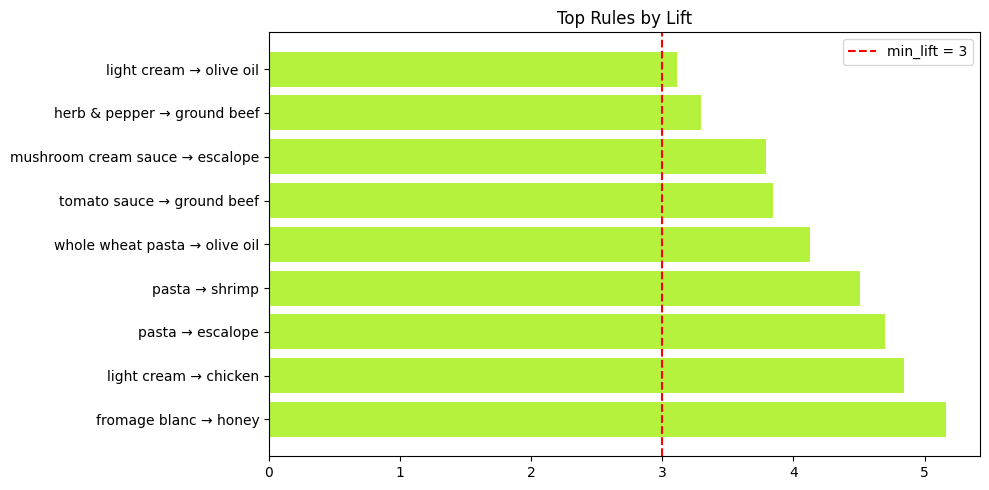

In [11]:
labels = [f"{r.LHS} → {r.RHS}" for _, r in df.iterrows()]

plt.figure(figsize=(10, 5))
plt.barh(labels, df['Lift'], color='#b5f23d')
plt.axvline(3, color='red', ls='--', label='min_lift = 3')
plt.title('Top Rules by Lift')
plt.legend()
plt.tight_layout()
plt.show()